##Evaluación 3 Big Data
###Análisis de incendios forestales e infraestructura crítica en Chile

Autores: Álvaro Flores - Aurora Mansilla

###Fase 1: Business Understanding

### Contexto

Los incendios forestales representan una amenaza para la infraestructura crítica de salud en Chile. El proyecto busca integrar información histórica de incendios, establecimientos de salud y variables meteorológicas para identificar zonas de riesgo y apoyar la toma de decisiones mediante alertas tempranas.

### Objetivo General

Analizar la evolución de los patrones espaciales y temporales de incendios forestales en Chile mediante técnicas de clustering aplicadas a datos históricos de las temporadas 2002-2003, 2014-2015 y 2019-2020, utilizando la metodología CRISP-DM y una Arquitectura Lambda para el procesamiento de grandes volúmenes de datos.

### Objetivos Específicos

- Analizar el comportamiento histórico de los incendios forestales.
- Integrar información geográfica de infraestructura de salud.
- Incorporar variables meteorológicas relevantes.
- Estimar niveles de riesgo para los establecimientos de salud.
- Visualizar resultados mediante un dashboard.

### Métricas de Éxito
- Precisión del modelo predictivo.
- Tiempo de procesamiento de eventos en tiempo real.
- Capacidad de integrar datos históricos y nuevos registros.
- Calidad de los reportes generados.

###Relación con Arquitectura Lambda

- Batch Layer: almacenamiento y procesamiento de datos históricos.
- Speed Layer: procesamiento de nuevos incendios en tiempo real.
- Serving Layer: consultas y visualización de resultados.

###Fase 2: Data Understanding




**Objetivo de la fase**

Comprender la estructura, calidad y características de los datos históricos de incendios forestales para identificar variables relevantes que permitan detectar patrones y zonas de riesgo mediante técnicas de clustering.

**Propósito de cada rango de años:**

- 2002-2003:	Patrón histórico inicial
- 2014-2015:	Comparación intermedia
- 2019-2020:	Situación reciente

In [ ]:
import pandas as pd

df_2002 = pd.read_csv("/20022003.csv")
df_2014 = pd.read_csv("/20142015.csv")
df_2019 = pd.read_csv("/20192020.csv")

print(df_2002.shape)
print(df_2014.shape)
print(df_2019.shape)

(7400, 1)
(8072, 1)
(8125, 1)


In [ ]:
df_2002 = pd.read_csv("/20022003.csv", sep="|", encoding="latin1")
df_2002["RegiÃ³n"].value_counts()

,count
RegiÃ³n,
BiobÃ­o,3183
AraucanÃ­a,1536
ValparaÃ­so,1084
Metropolitana,573
Maule,512
O'Higgins,222
Los Lagos,141
Los RÃ­os,74
Coquimbo,72


In [ ]:
df_2014 = pd.read_csv("/20022003.csv", sep="|", encoding="latin1")
df_2014["RegiÃ³n"].value_counts()

,count
RegiÃ³n,
BiobÃ­o,3183
AraucanÃ­a,1536
ValparaÃ­so,1084
Metropolitana,573
Maule,512
O'Higgins,222
Los Lagos,141
Los RÃ­os,74
Coquimbo,72


In [ ]:
df_2019= pd.read_csv("/20022003.csv", sep="|", encoding="latin1")
df_2019["RegiÃ³n"].value_counts()

,count
RegiÃ³n,
BiobÃ­o,3183
AraucanÃ­a,1536
ValparaÃ­so,1084
Metropolitana,573
Maule,512
O'Higgins,222
Los Lagos,141
Los RÃ­os,74
Coquimbo,72


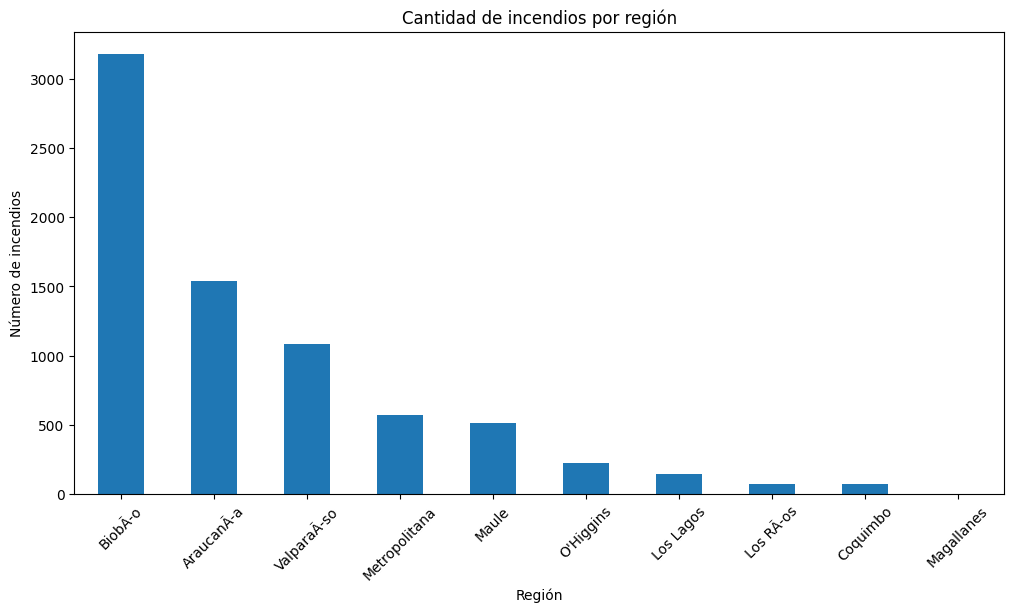

In [ ]:
import matplotlib.pyplot as plt

df = df.rename(columns={'RegiÃ³n': 'Región'})

incendios_region = (
    df.groupby("Región")
      .size()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

incendios_region.plot(kind="bar")

plt.title("Cantidad de incendios por región")
plt.xlabel("Región")
plt.ylabel("Número de incendios")

plt.xticks(rotation=45)
plt.show()

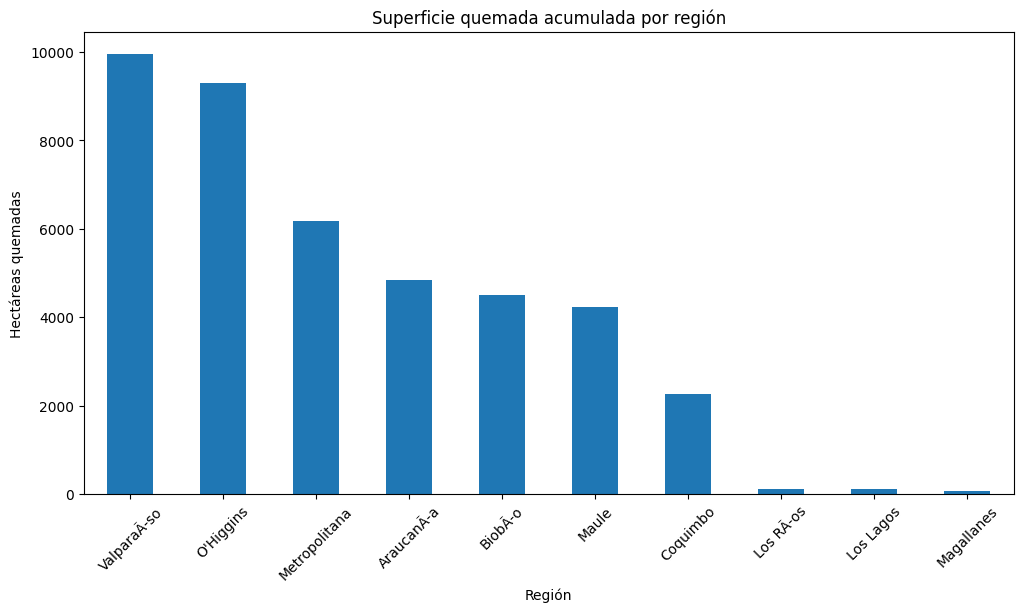

In [ ]:
superficie_region = (
    df.groupby("Región")
      ["Superficie quemada total [ha]"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

superficie_region.plot(kind="bar")

plt.title("Superficie quemada acumulada por región")
plt.xlabel("Región")
plt.ylabel("Hectáreas quemadas")

plt.xticks(rotation=45)
plt.show()

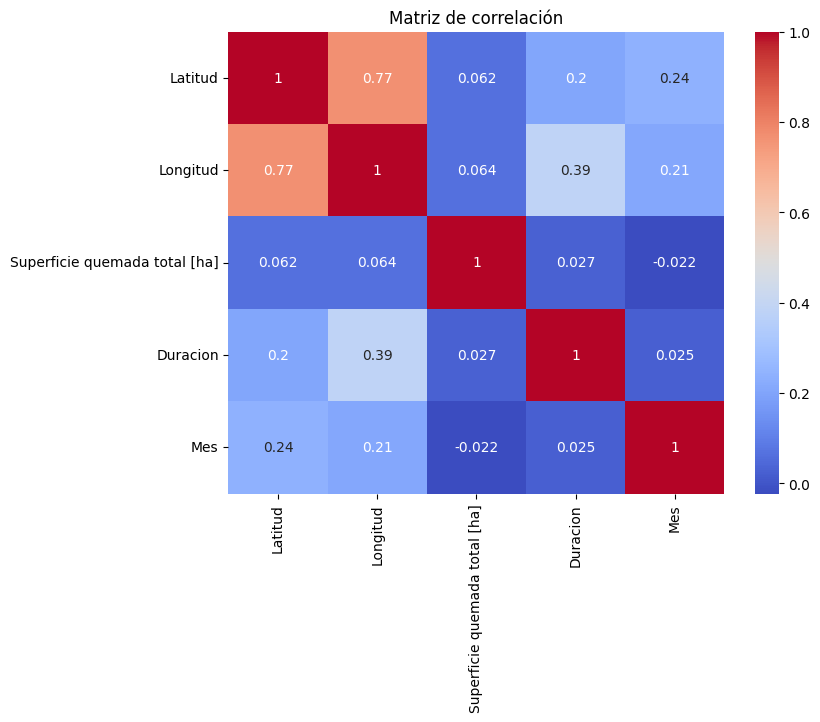

In [ ]:
import seaborn as sns

df = df.rename(columns={'DuraciÃ³n (minutos)': 'Duracion'})

variables = df[
    [
        "Latitud",
        "Longitud",
        "Superficie quemada total [ha]",
        "Duracion",
        "Mes"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    variables.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de correlación")
plt.show()

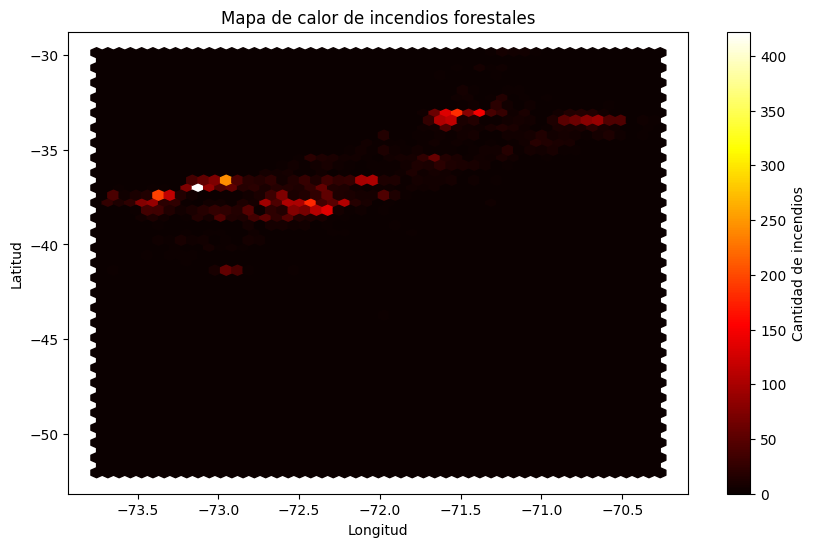

In [ ]:
plt.figure(figsize=(10,6))

plt.hexbin(
    df["Longitud"],
    df["Latitud"],
    gridsize=50,
    cmap="hot"
)

plt.colorbar(label="Cantidad de incendios")

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de calor de incendios forestales")

plt.show()

###Fase 3: Data Preparation

In [ ]:
df = pd.concat(
    [df_2002, df_2014, df_2019],
    ignore_index=True
)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df.dropna(
    subset=[
        "Latitud",
        "Longitud",
        "Superficie quemada total [ha]"
    ]
)

In [ ]:
df["Fecha"] = pd.to_datetime(
    df["Fecha"],
    errors="coerce"
)

In [ ]:
df["Año"] = df["Fecha"].dt.year
df["Mes"] = df["Fecha"].dt.month

In [ ]:
X = df[
    [
        "Latitud",
        "Longitud",
        "Superficie quemada total [ha]",
        "DuraciÃ³n (minutos)",
        "Mes"
    ]
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

###Relación con Arquitectura Lambda
- **Batch Layer**

- Datos históricos 2002-2003.
- Datos históricos 2014-2015.
- Datos históricos 2019-2020.
- **Speed Layer**

- Nuevos registros de incendios futuros.
- **Serving Layer**

- Consulta de zonas de riesgo detectadas.

###Fase 4: Modelado

###DBSCAN

Se selecciona DBSCAN debido a que:

No requiere definir previamente el número de clusters.
Detecta agrupaciones espaciales naturales.
Identifica ruido y eventos aislados.
Es adecuado para coordenadas geográficas.

In [ ]:
from sklearn.cluster import DBSCAN

modelo = DBSCAN(
    eps=0.3,
    min_samples=10
)

clusters = modelo.fit_predict(X_scaled)

In [ ]:
df["Cluster"] = clusters

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

modelo = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

labels = modelo.fit_predict(X_scaled)

print("Silhouette:", silhouette_score(X_scaled, labels))
print("Davies:", davies_bouldin_score(X_scaled, labels))

Silhouette: 0.5582833402852316
Davies: 0.5926387432445587


In [ ]:
from sklearn.cluster import AgglomerativeClustering

modelo = AgglomerativeClustering(
    n_clusters=5
)

labels = modelo.fit_predict(X_scaled)

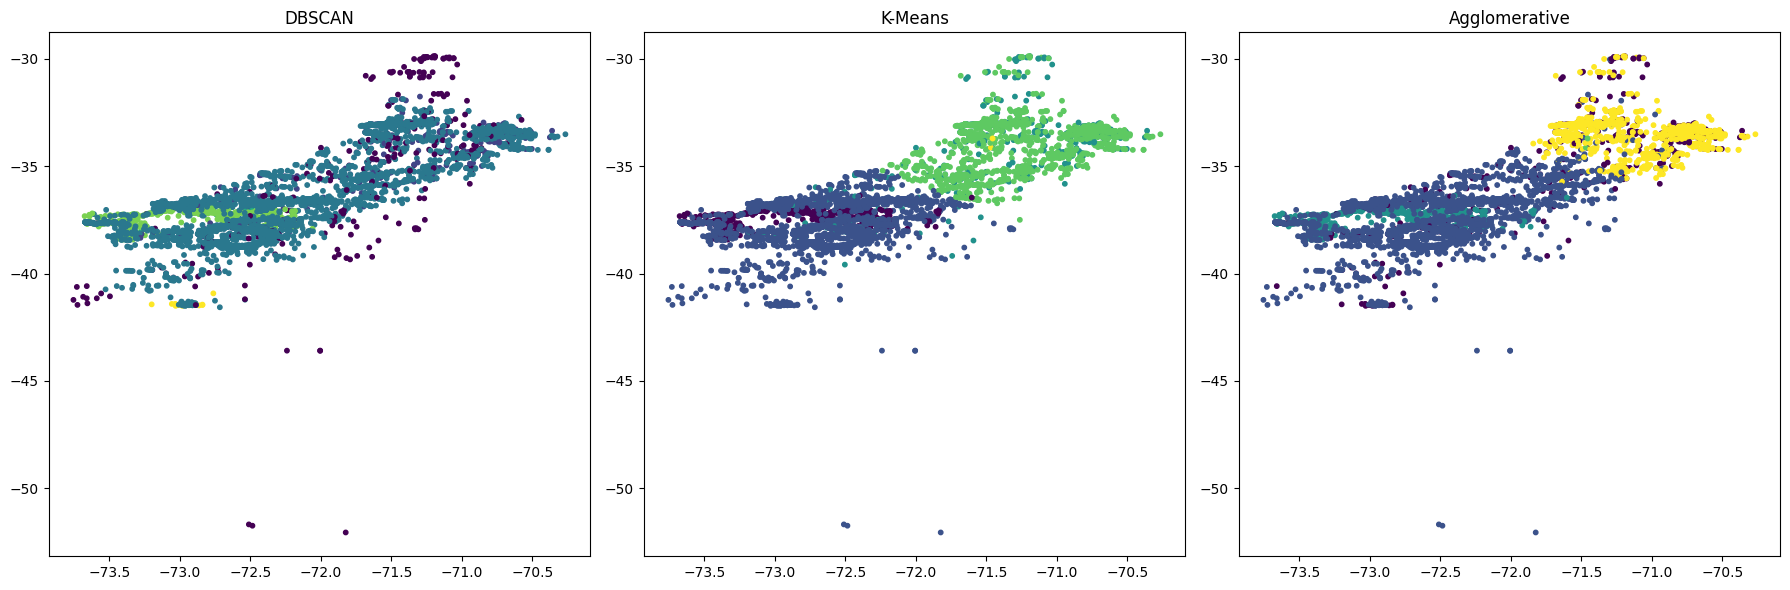

In [ ]:
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering

dbscan_labels = clusters

kmeans_model = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_scaled)

agg_model = AgglomerativeClustering(n_clusters=5)
agg_labels = agg_model.fit_predict(X_scaled)

fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].scatter(
    df["Longitud"],
    df["Latitud"],
    c=dbscan_labels,
    s=10
)
ax[0].set_title("DBSCAN")

ax[1].scatter(
    df["Longitud"],
    df["Latitud"],
    c=kmeans_labels,
    s=10
)
ax[1].set_title("K-Means")

ax[2].scatter(
    df["Longitud"],
    df["Latitud"],
    c=agg_labels,
    s=10
)
ax[2].set_title("Agglomerative")

plt.tight_layout()
plt.show()

###Fase 5: Evaluación

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

resultados = []

# DBSCAN
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    sil_dbscan = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    db_dbscan = davies_bouldin_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    resultados.append([
        "DBSCAN",
        sil_dbscan,
        db_dbscan
    ])

# KMeans
sil_kmeans = silhouette_score(
    X_scaled,
    kmeans_labels
)

db_kmeans = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

resultados.append([
    "K-Means",
    sil_kmeans,
    db_kmeans
])

# Agglomerative
sil_agg = silhouette_score(
    X_scaled,
    agg_labels
)

db_agg = davies_bouldin_score(
    X_scaled,
    agg_labels
)

resultados.append([
    "Agglomerative",
    sil_agg,
    db_agg
])



In [ ]:
metricas_ordenadas = metricas.sort_values(
    by=["Silhouette", "Davies_Bouldin"],
    ascending=[False, True]
).reset_index(drop=True)

metricas_ordenadas.index += 1

print(metricas_ordenadas)

          Modelo  Silhouette  Davies_Bouldin
1        K-Means    0.558283        0.592639
2  Agglomerative    0.539545        0.593500
3         DBSCAN    0.489027        0.621040


###Fase 6: Despliegue